<a href="https://www.kaggle.com/code/sonawanelalitsunil/usa-house-sales-data-ml-32-8?scriptVersionId=248774883" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/usa-house-sales-data/us_house_Sales_data.csv


## USA House Sales Data

## Description:
This dataset contains detailed information on house sales across various regions in the United States. It includes features such as property location, sale price, number of bedrooms and bathrooms, square footage, lot size, year built, and more. The data can be used for exploratory data analysis, price prediction using machine learning models, trend analysis over time, and identifying factors that influence housing prices.


## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/usa-house-sales-data/us_house_Sales_data.csv')

In [3]:
df.head()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
0,"$554,217","5926 Oak Ave, San Diego, CA 65383",San Diego,65383,CA,1 bds,3 ba,772 sqft,4757 sqft,1959,101,Townhouse,Z104635,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/80374762_zpid/
1,"$164,454","9583 Oak Ave, Fresno, IL 79339",Fresno,79339,IL,1 bds,1 ba,2348 sqft,3615 sqft,1969,46,Apartment,Z535721,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/86143665_zpid/
2,"$1,249,331","8224 Oak Ave, Sacramento, TX 87393",Sacramento,87393,TX,6 bds,1 ba,3630 sqft,9369 sqft,1990,59,Townhouse,Z900458,Mike Lee - Coldwell Banker,For Sale,https://www.zillow.com/homedetails/37082403_zpid/
3,"$189,267","232 Oak Ave, Fresno, TX 38666",Fresno,38666,TX,2 bds,1 ba,605 sqft,8804 sqft,1958,119,Apartment,Z318589,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/39318132_zpid/
4,"$465,778","5446 Pine Rd, Los Angeles, CA 23989",Los Angeles,23989,CA,3 bds,2 ba,1711 sqft,9260 sqft,2020,26,Townhouse,Z899716,John Doe - RE/MAX,Pending,https://www.zillow.com/homedetails/22454634_zpid/


In [4]:
df.tail()

,Price,Address,City,Zipcode,State,Bedrooms,Bathrooms,Area (Sqft),Lot Size,Year Built,Days on Market,Property Type,MLS ID,Listing Agent,Status,Listing URL
2995,"$801,824","4167 Oak Ave, San Diego, TX 78499",San Diego,78499,TX,3 bds,4 ba,3318 sqft,6745 sqft,2022,61,Multi-Family,Z284935,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/50860042_zpid/
2996,"$843,703","5606 Pine Rd, Sacramento, CA 39627",Sacramento,39627,CA,6 bds,2 ba,900 sqft,8046 sqft,2012,64,Multi-Family,Z842214,Emily Davis - Century 21,Sold,https://www.zillow.com/homedetails/33603937_zpid/
2997,"$743,513","6230 Maple Dr, Fresno, TX 62804",Fresno,62804,TX,4 bds,3 ba,2921 sqft,2041 sqft,2005,48,Multi-Family,Z350999,Jane Smith - Keller Williams,Sold,https://www.zillow.com/homedetails/44710479_zpid/
2998,"$211,664","8683 Main St, San Diego, TX 99740",San Diego,99740,TX,2 bds,4 ba,701 sqft,1344 sqft,2017,117,Single Family,Z748192,Alex Johnson - Compass,Pending,https://www.zillow.com/homedetails/41368665_zpid/
2999,"$712,029","4392 Maple Dr, Los Angeles, NY 89198",Los Angeles,89198,NY,4 bds,3 ba,2967 sqft,8071 sqft,1985,32,Condo,Z876426,Alex Johnson - Compass,For Sale,https://www.zillow.com/homedetails/64854326_zpid/


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           3000 non-null   object
 1   Address         3000 non-null   object
 2   City            3000 non-null   object
 3   Zipcode         3000 non-null   int64 
 4   State           3000 non-null   object
 5   Bedrooms        3000 non-null   object
 6   Bathrooms       3000 non-null   object
 7   Area (Sqft)     3000 non-null   object
 8   Lot Size        3000 non-null   object
 9   Year Built      3000 non-null   int64 
 10  Days on Market  3000 non-null   int64 
 11  Property Type   3000 non-null   object
 12  MLS ID          3000 non-null   object
 13  Listing Agent   3000 non-null   object
 14  Status          3000 non-null   object
 15  Listing URL     3000 non-null   object
dtypes: int64(3), object(13)
memory usage: 375.1+ KB


In [6]:
df.describe()

,Zipcode,Year Built,Days on Market
count,3000.000000,3000.000000,3000.000000
mean,55264.197333,1986.814333,61.199333
std,25923.967932,21.272252,34.890983
min,10006.000000,1950.000000,1.000000
25%,33363.500000,1968.000000,31.000000
50%,55467.500000,1987.000000,62.000000
75%,77692.250000,2006.000000,91.000000
max,99955.000000,2023.000000,120.000000


In [7]:
df.isnull().sum()

Price             0
Address           0
City              0
Zipcode           0
State             0
Bedrooms          0
Bathrooms         0
Area (Sqft)       0
Lot Size          0
Year Built        0
Days on Market    0
Property Type     0
MLS ID            0
Listing Agent     0
Status            0
Listing URL       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(3000, 16)

In [10]:
df.dtypes

Price             object
Address           object
City              object
Zipcode            int64
State             object
Bedrooms          object
Bathrooms         object
Area (Sqft)       object
Lot Size          object
Year Built         int64
Days on Market     int64
Property Type     object
MLS ID            object
Listing Agent     object
Status            object
Listing URL       object
dtype: object

In [11]:
df.columns

Index(['Price', 'Address', 'City', 'Zipcode', 'State', 'Bedrooms', 'Bathrooms',
       'Area (Sqft)', 'Lot Size', 'Year Built', 'Days on Market',
       'Property Type', 'MLS ID', 'Listing Agent', 'Status', 'Listing URL'],
      dtype='object')

## Data visualizations

<Axes: xlabel='Price', ylabel='Count'>

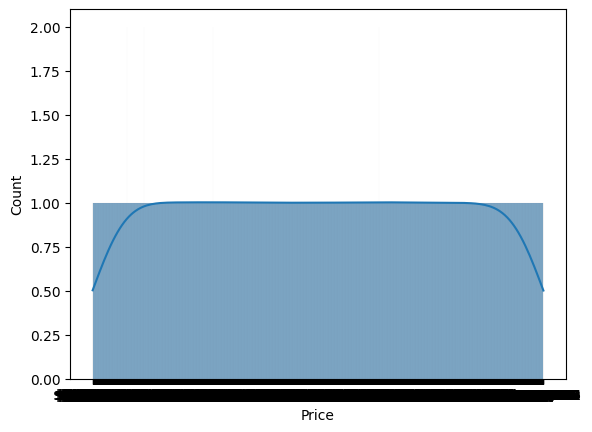

In [12]:
sns.histplot(df['Price'], bins=50, kde=True)

<Axes: xlabel='Area (Sqft)', ylabel='Price'>

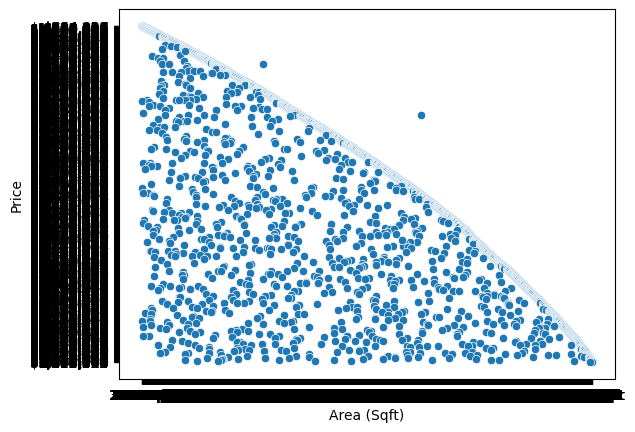

In [13]:
sns.scatterplot(data=df, x='Area (Sqft)', y='Price')

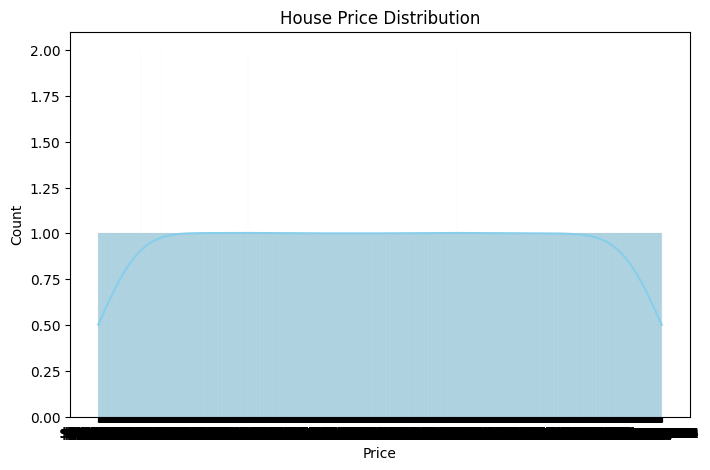

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True, color='skyblue')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


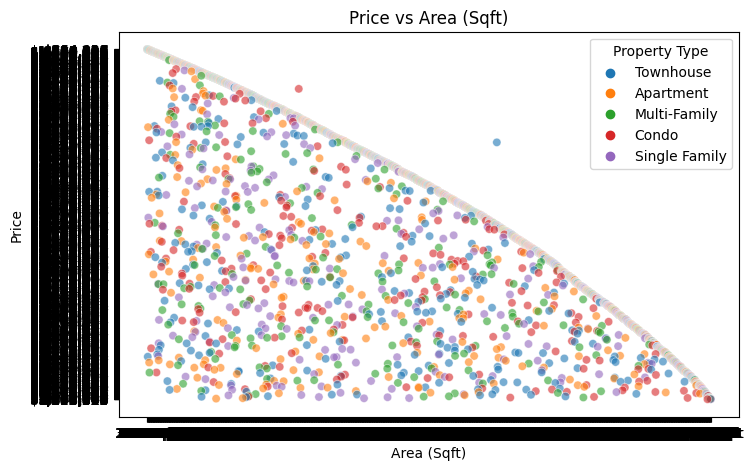

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Area (Sqft)', y='Price', hue='Property Type', alpha=0.6)
plt.title('Price vs Area (Sqft)')
plt.xlabel('Area (Sqft)')
plt.ylabel('Price')
plt.show()


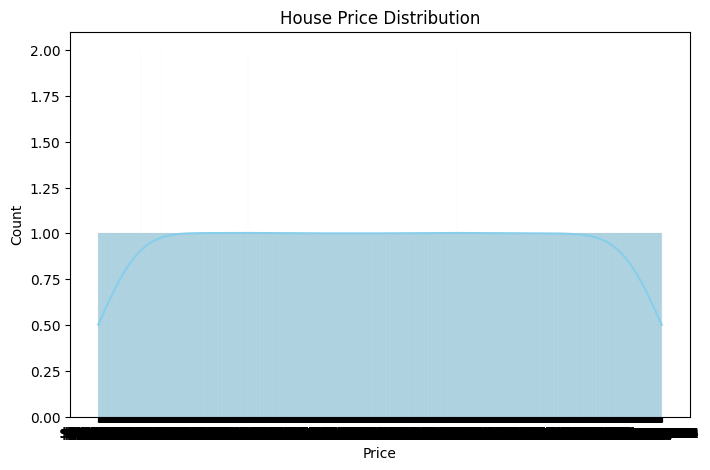

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, kde=True, color='skyblue')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


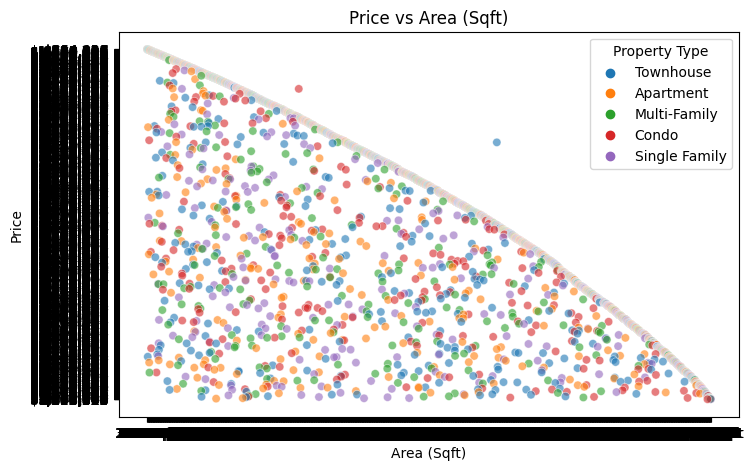

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Area (Sqft)', y='Price', hue='Property Type', alpha=0.6)
plt.title('Price vs Area (Sqft)')
plt.xlabel('Area (Sqft)')
plt.ylabel('Price')
plt.show()


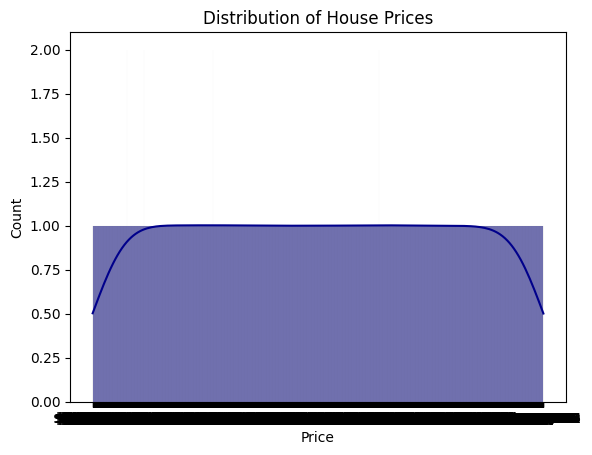

In [18]:
# 1. Price Distribution
sns.histplot(df['Price'], bins=50, kde=True, color='darkblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

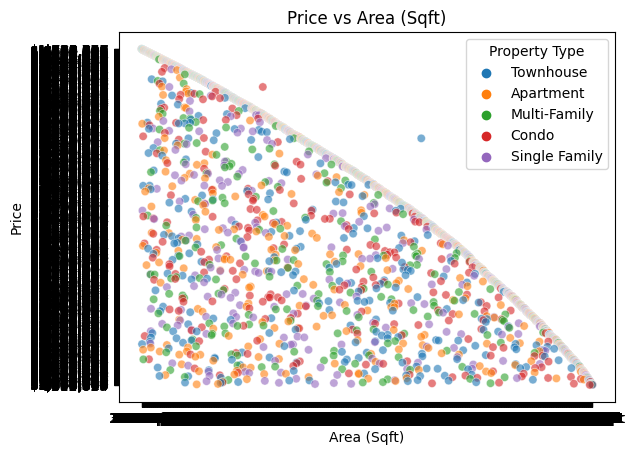

In [19]:
# 4. Area vs Price
sns.scatterplot(data=df, x='Area (Sqft)', y='Price', hue='Property Type', alpha=0.6)
plt.title('Price vs Area (Sqft)')
plt.show()

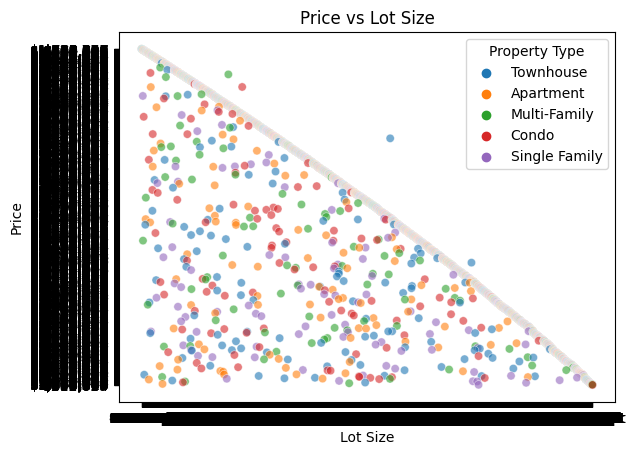

In [20]:
# 5. Lot Size vs Price
sns.scatterplot(data=df, x='Lot Size', y='Price', hue='Property Type', alpha=0.6)
plt.title('Price vs Lot Size')
plt.show()


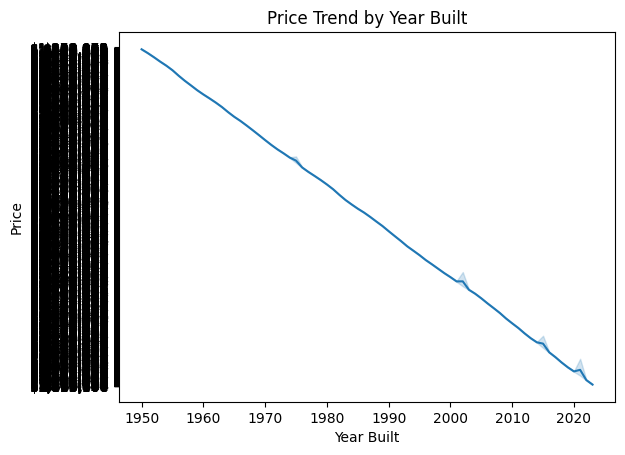

In [21]:
# 6. Year Built vs Price
sns.lineplot(data=df.sort_values('Year Built'), x='Year Built', y='Price')
plt.title('Price Trend by Year Built')
plt.show()


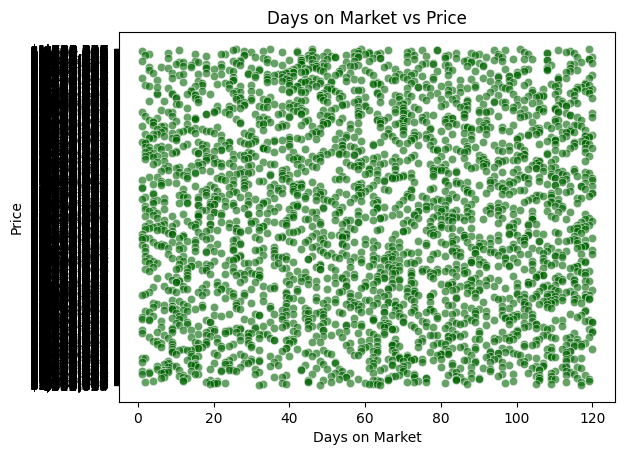

In [22]:
# 7. Days on Market vs Price
sns.scatterplot(data=df, x='Days on Market', y='Price', alpha=0.6, color='darkgreen')
plt.title('Days on Market vs Price')
plt.show()


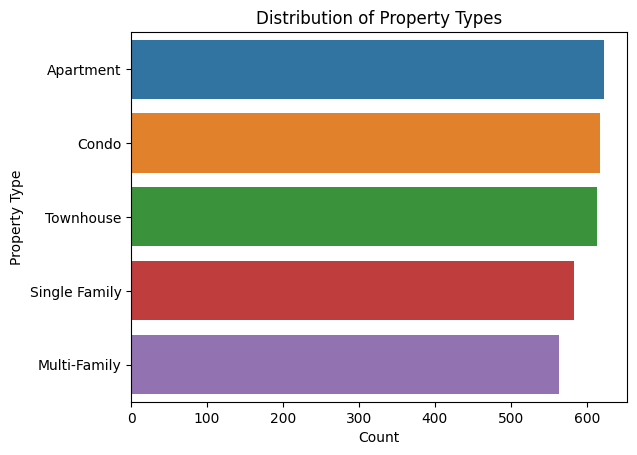

In [23]:
# 8. Property Type Distribution
sns.countplot(data=df, y='Property Type', order=df['Property Type'].value_counts().index)
plt.title('Distribution of Property Types')
plt.xlabel('Count')
plt.ylabel('Property Type')
plt.show()

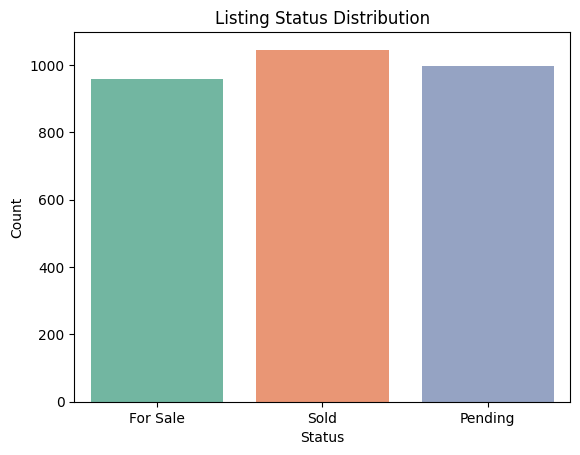

In [24]:
# 9. Status of Listings
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Listing Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

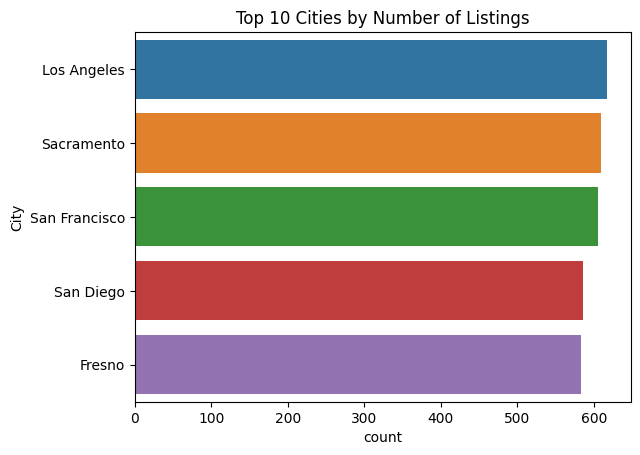

In [25]:
# 10. Listings by City (Top 10)
top_cities = df['City'].value_counts().nlargest(10).index
sns.countplot(data=df[df['City'].isin(top_cities)], y='City', order=top_cities)
plt.title('Top 10 Cities by Number of Listings')
plt.show()

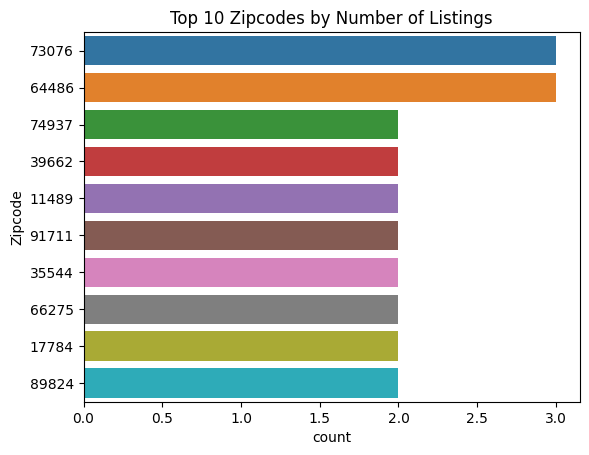

In [26]:
# 11. Listings by Zipcode (Top 10)
top_zip = df['Zipcode'].value_counts().nlargest(10).index
sns.countplot(data=df[df['Zipcode'].isin(top_zip)], y='Zipcode', order=top_zip)
plt.title('Top 10 Zipcodes by Number of Listings')
plt.show()

## Predictive modeling

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [28]:
print("Initial columns:", df.columns)

Initial columns: Index(['Price', 'Address', 'City', 'Zipcode', 'State', 'Bedrooms', 'Bathrooms',
       'Area (Sqft)', 'Lot Size', 'Year Built', 'Days on Market',
       'Property Type', 'MLS ID', 'Listing Agent', 'Status', 'Listing URL'],
      dtype='object')


In [29]:
# ------------------- STEP 1: Clean -------------------
print("Original shape:", df.shape)

# Drop irrelevant or high-cardinality columns
df = df.drop(['Address', 'MLS ID', 'Listing Agent', 'Listing URL'], axis=1, errors='ignore')

# Clean money fields (e.g., '$121,284' → 121284)
money_cols = ['Price', 'Area (Sqft)', 'Lot Size']
for col in money_cols:
    if col in df.columns:
        df[col] = df[col].replace('[\$,]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop only rows where target 'Status' is missing
df = df.dropna(subset=['Status'])

# Fill missing numeric columns with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical columns with most frequent
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Cleaned shape:", df.shape)
if df.empty:
    raise ValueError("DataFrame is empty after cleaning. Check raw data source.")

# ------------------- STEP 2: Features and Target -------------------
X = df.drop('Status', axis=1)
y = df['Status']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ------------------- STEP 3: Preprocessor -------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformations and convert to dense (required for GaussianNB)
preprocessor = Pipeline(steps=[
    ('column_transform', ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True))
])

# ------------------- STEP 4: Split -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Original shape: (3000, 16)
Cleaned shape: (3000, 12)


In [30]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [31]:
# ------------------- STEP: Define Models -------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

# ------------------- STEP: Evaluate Models -------------------
results = {}

for name, model in models.items():
    if name == 'Naive Bayes':
        # Naive Bayes doesn't support sparse input
        X_train_trans = preprocessor.fit_transform(X_train)
        X_test_trans = preprocessor.transform(X_test)
        
        X_train_dense = X_train_trans.toarray() if hasattr(X_train_trans, 'toarray') else X_train_trans
        X_test_dense = X_test_trans.toarray() if hasattr(X_test_trans, 'toarray') else X_test_trans
        
        model.fit(X_train_dense, y_train)
        y_pred = model.predict(X_test_dense)
    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"{name}: {acc:.2f}% accuracy")


Logistic Regression: 35.33% accuracy
Decision Tree: 33.17% accuracy
Random Forest: 32.00% accuracy
Naive Bayes: 32.17% accuracy
SVM: 32.83% accuracy
KNN: 30.67% accuracy


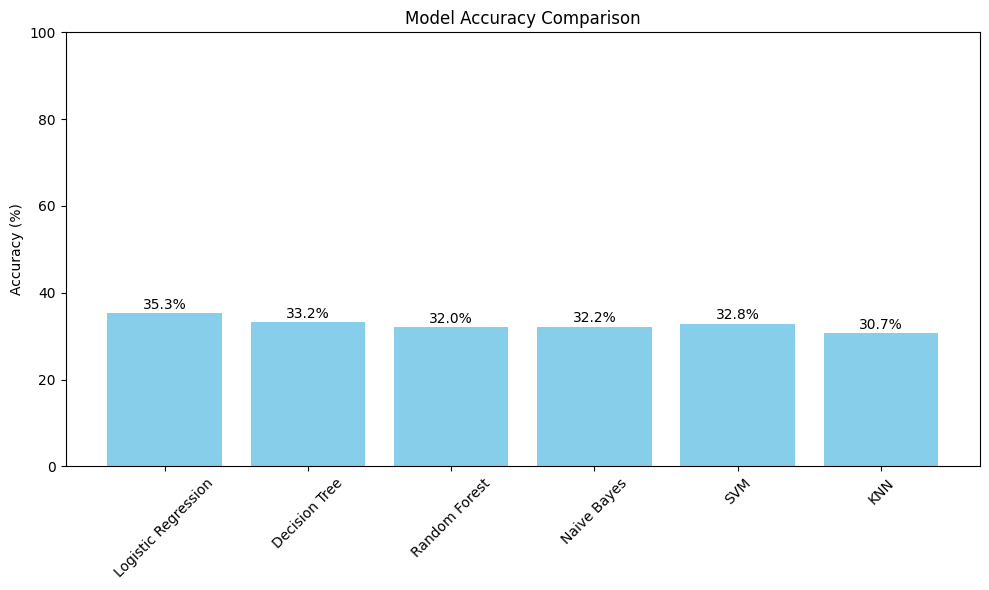

In [32]:
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
for i, v in enumerate(results.values()):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Thank you pls upvote!!!